In [1]:
# Install Dependencies

!pip install xgboost shap imbalanced-learn lightgbm --quiet

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
# Upload Dataset

from google.colab import files
uploaded = files.upload()

Saving feature-engineered-data.csv to feature-engineered-data.csv


In [5]:
# Load Dataset

df = pd.read_csv("feature-engineered-data.csv")
print("Dataset shape:", df.shape)
print("Attrition distribution:\n", df["Attrition"].value_counts())

Dataset shape: (1470, 51)
Attrition distribution:
 Attrition
0    1233
1     237
Name: count, dtype: int64


In [6]:
# Split Features and Target

X = df.drop("Attrition", axis=1)
y = df["Attrition"]
print(f"\nFeature count: {X.shape[1]}")
print("Features:", X.columns.tolist())


Feature count: 50
Features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'IncomePerYear', 'PromotionGap', 'CompanyExperienceRatio', 'ManagerStability', 'WorkloadScore', 'SalaryGrowth', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research

In [7]:
# Train-Test Split (stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"Train attrition rate: {y_train.mean():.2%}")
print(f"Test attrition rate:  {y_test.mean():.2%}")


Train size: 1176
Test size:  294
Train attrition rate: 16.16%
Test attrition rate:  15.99%


In [8]:
#  Handle Class Imbalance with SMOTE

print("\nOriginal train distribution:")
print(y_train.value_counts())
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("\nResampled train distribution:")
print(pd.Series(y_train_res).value_counts())


Original train distribution:
Attrition
0    986
1    190
Name: count, dtype: int64

Resampled train distribution:
Attrition
0    986
1    986
Name: count, dtype: int64


In [9]:
# TRAINING ALL THREE MODELS

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [10]:
# 1. Logistic Regression

print("\n" + "="*50)
print("Training Logistic Regression...")
lr_params = {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs"]}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params, cv=cv, scoring="recall", n_jobs=-1, verbose=0
)
lr_grid.fit(X_train_res, y_train_res)
lr_model = lr_grid.best_estimator_
print(f"Best params: {lr_grid.best_params_}")
print(f"Best CV Recall: {lr_grid.best_score_:.4f}")



Training Logistic Regression...
Best params: {'C': 1, 'solver': 'lbfgs'}
Best CV Recall: 0.8052


In [11]:
# 2. Random Forest

print("\n" + "="*50)
print("Training Random Forest...")
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=cv, scoring="recall", n_jobs=-1, verbose=0
)
rf_grid.fit(X_train_res, y_train_res)
rf_model = rf_grid.best_estimator_
print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV Recall: {rf_grid.best_score_:.4f}")


Training Random Forest...
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Recall: 0.9148


In [12]:
# 3. XGBoost

print("\n" + "="*50)
print("Training XGBoost...")
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}
xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    xgb_params, cv=cv, scoring="recall", n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train_res, y_train_res)
xgb_model = xgb_grid.best_estimator_
print(f"Best params: {xgb_grid.best_params_}")
print(f"Best CV Recall: {xgb_grid.best_score_:.4f}")



Training XGBoost...
Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best CV Recall: 0.9117


In [13]:
# CUSTOM THRESHOLD (0.3) EVALUATION
# Business reason: Missing an at-risk employee (False Negative)
# is far more costly than a false alarm (False Positive).
# Lowering threshold from 0.5 → 0.3 maximizes Recall.

THRESHOLD = 0.3

def evaluate_with_threshold(model, X_test, y_test, threshold=0.3, name="Model"):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cm   = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f"{name} @ threshold={threshold}")
    print(f"{'='*50}")
    print(f"Accuracy  : {acc:.4f} ({acc*100:.1f}%)")
    print(f"Recall    : {rec:.4f} ({rec*100:.1f}%)")
    print(f"Precision : {prec:.4f} ({prec*100:.1f}%)")
    print(f"F1 Score  : {f1:.4f} ({f1*100:.1f}%)")
    print(f"AUC-ROC   : {auc:.4f} ({auc*100:.1f}%)")
    print(f"\nConfusion Matrix:")
    print(f"  TN={cm[0][0]}  FP={cm[0][1]}")
    print(f"  FN={cm[1][0]}  TP={cm[1][1]}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return {
        "Model": name,
        "Accuracy": round(acc * 100, 1),
        "Recall": round(rec * 100, 1),
        "Precision": round(prec * 100, 1),
        "F1": round(f1 * 100, 1),
        "AUC": round(auc * 100, 1),
        "Confusion Matrix": cm.tolist(),
        "y_prob": y_prob,
        "y_pred": y_pred
    }

print("\n\n" + "="*60)
print("EVALUATING ALL MODELS WITH THRESHOLD = 0.3")
print("="*60)

lr_results  = evaluate_with_threshold(lr_model,  X_test, y_test, THRESHOLD, "Logistic Regression")
rf_results  = evaluate_with_threshold(rf_model,  X_test, y_test, THRESHOLD, "Random Forest")
xgb_results = evaluate_with_threshold(xgb_model, X_test, y_test, THRESHOLD, "XGBoost")



EVALUATING ALL MODELS WITH THRESHOLD = 0.3

Logistic Regression @ threshold=0.3
Accuracy  : 0.6565 (65.6%)
Recall    : 0.7660 (76.6%)
Precision : 0.2857 (28.6%)
F1 Score  : 0.4162 (41.6%)
AUC-ROC   : 0.7862 (78.6%)

Confusion Matrix:
  TN=157  FP=90
  FN=11  TP=36

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76       247
           1       0.29      0.77      0.42        47

    accuracy                           0.66       294
   macro avg       0.61      0.70      0.59       294
weighted avg       0.83      0.66      0.70       294


Random Forest @ threshold=0.3
Accuracy  : 0.7823 (78.2%)
Recall    : 0.7234 (72.3%)
Precision : 0.4000 (40.0%)
F1 Score  : 0.5152 (51.5%)
AUC-ROC   : 0.8099 (81.0%)

Confusion Matrix:
  TN=196  FP=51
  FN=13  TP=34

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       247
           1       0.40      0.72

In [14]:
# Summary Table

summary = pd.DataFrame([
    {k: v for k, v in lr_results.items()  if k not in ["y_prob","y_pred","Confusion Matrix"]},
    {k: v for k, v in rf_results.items()  if k not in ["y_prob","y_pred","Confusion Matrix"]},
    {k: v for k, v in xgb_results.items() if k not in ["y_prob","y_pred","Confusion Matrix"]},
])
print("\n\n" + "="*60)
print("FINAL SUMMARY TABLE")
print("="*60)
print(summary.to_string(index=False))



FINAL SUMMARY TABLE
              Model  Accuracy  Recall  Precision   F1  AUC
Logistic Regression      65.6    76.6       28.6 41.6 78.6
      Random Forest      78.2    72.3       40.0 51.5 81.0
            XGBoost      86.4    44.7       60.0 51.2 79.0


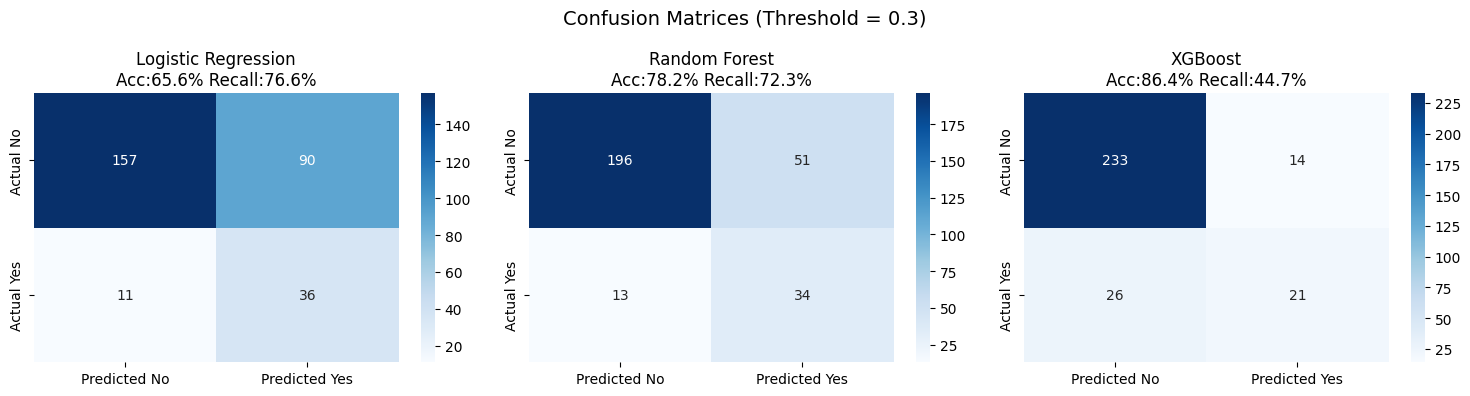

In [15]:
# Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, res, name in zip(axes,
    [lr_results, rf_results, xgb_results],
    ["Logistic Regression", "Random Forest", "XGBoost"]):
    cm = np.array(res["Confusion Matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Predicted No","Predicted Yes"],
                yticklabels=["Actual No","Actual Yes"])
    ax.set_title(f"{name}\nAcc:{res['Accuracy']}% Recall:{res['Recall']}%")
plt.suptitle(f"Confusion Matrices (Threshold = {THRESHOLD})", fontsize=14)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

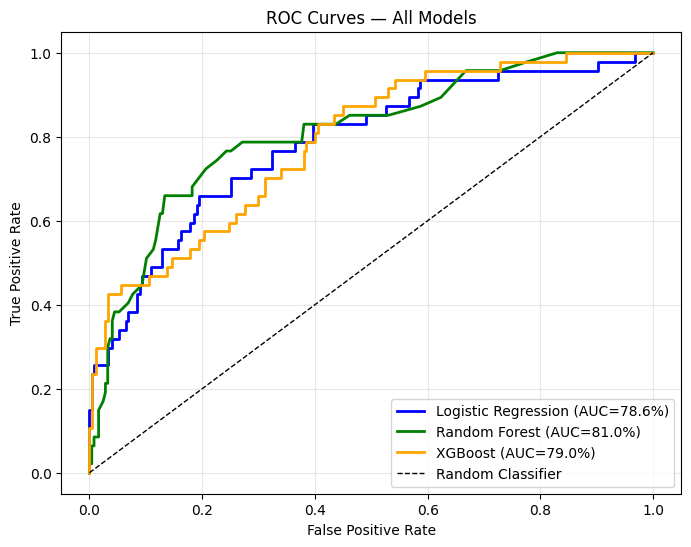

In [16]:
# ROC Curves

plt.figure(figsize=(8, 6))
for res, name, color in zip(
    [lr_results, rf_results, xgb_results],
    ["Logistic Regression", "Random Forest", "XGBoost"],
    ["blue", "green", "orange"]
):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={res['AUC']}%)")
plt.plot([0,1],[0,1],"k--", lw=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

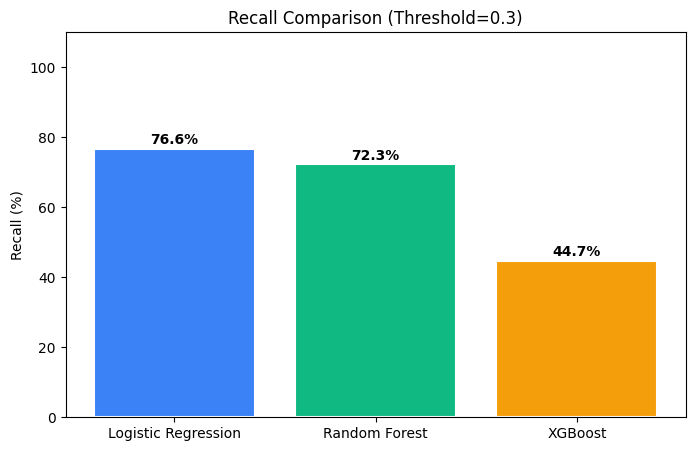

In [17]:
# Recall Comparison

plt.figure(figsize=(8, 5))
models_names = ["Logistic Regression", "Random Forest", "XGBoost"]
recalls = [lr_results["Recall"], rf_results["Recall"], xgb_results["Recall"]]
colors = ["#3b82f6", "#10b981", "#f59e0b"]
bars = plt.bar(models_names, recalls, color=colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, recalls):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val}%", ha="center", va="bottom", fontweight="bold")
plt.title(f"Recall Comparison (Threshold={THRESHOLD})")
plt.ylabel("Recall (%)")
plt.ylim(0, 110)
plt.savefig("recall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

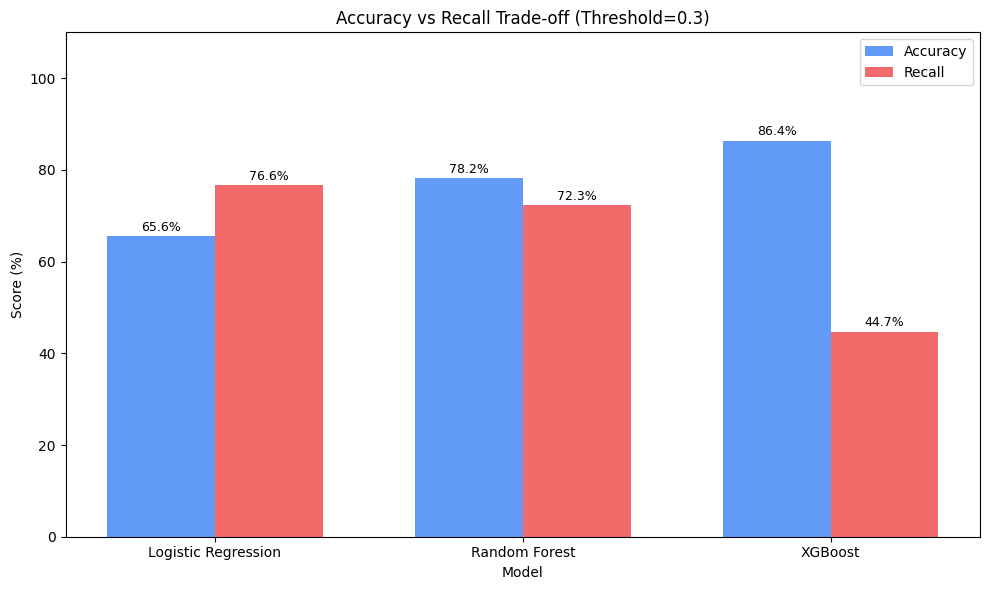

In [18]:
# Model Accuracy vs Recall

x = np.arange(len(models_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, [lr_results["Accuracy"], rf_results["Accuracy"], xgb_results["Accuracy"]],
               width, label="Accuracy", color="#3b82f6", alpha=0.8)
bars2 = ax.bar(x + width/2, recalls, width, label="Recall", color="#ef4444", alpha=0.8)
ax.set_xlabel("Model")
ax.set_ylabel("Score (%)")
ax.set_title(f"Accuracy vs Recall Trade-off (Threshold={THRESHOLD})")
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.legend()
ax.set_ylim(0, 110)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("accuracy_vs_recall.png", dpi=150, bbox_inches="tight")
plt.show()

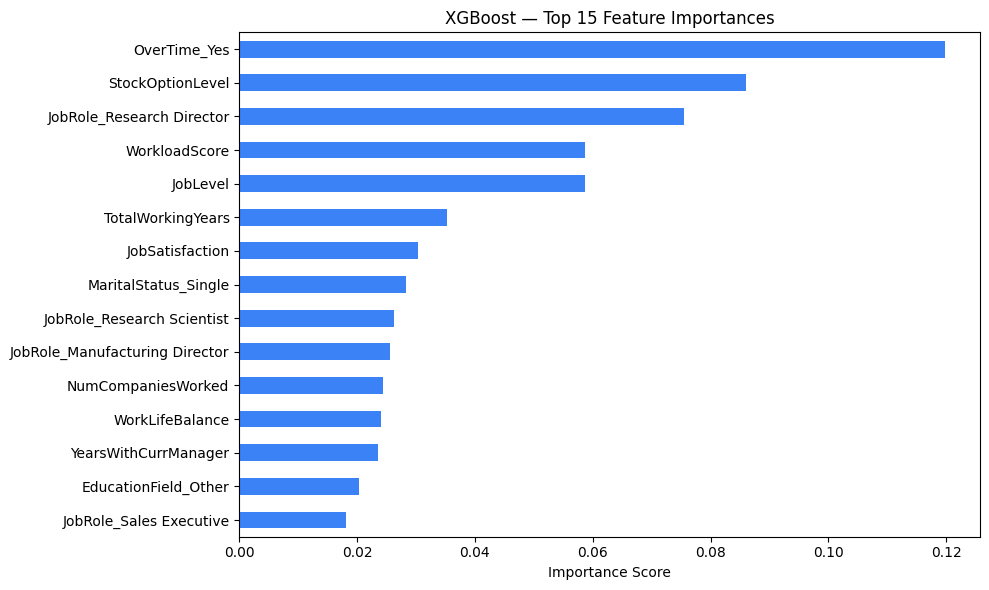


Top 15 Features:
OverTime_Yes                      0.119743
StockOptionLevel                  0.086097
JobRole_Research Director         0.075502
WorkloadScore                     0.058670
JobLevel                          0.058634
TotalWorkingYears                 0.035312
JobSatisfaction                   0.030338
MaritalStatus_Single              0.028270
JobRole_Research Scientist        0.026250
JobRole_Manufacturing Director    0.025590
NumCompaniesWorked                0.024342
WorkLifeBalance                   0.024014
YearsWithCurrManager              0.023595
EducationField_Other              0.020409
JobRole_Sales Executive           0.018121


In [19]:
# Feature Importance (XGBoost)
feat_imp = pd.Series(
    xgb_model.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind="barh", color="#3b82f6")
plt.title("XGBoost — Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 15 Features:")
print(feat_imp.to_string())

In [20]:
# SHAP EXPLAINER

print("\nGenerating SHAP explainer (XGBoost)...")
shap_explainer = shap.TreeExplainer(xgb_model)
shap_values = shap_explainer.shap_values(X_test)


Generating SHAP explainer (XGBoost)...


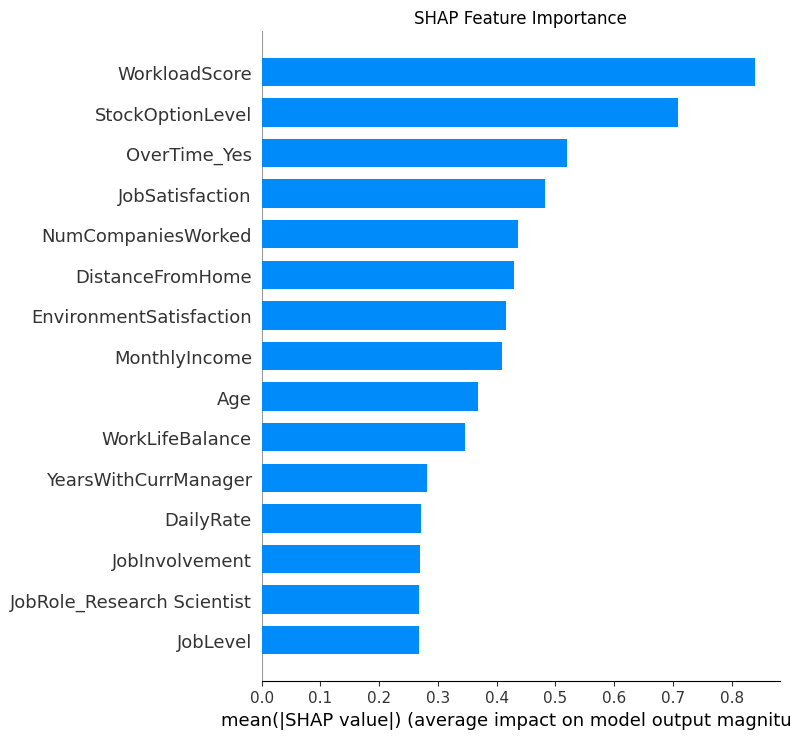

SHAP explainer ready


In [21]:
# SHAP summary plot

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=15)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP explainer ready")

In [22]:
# RETRAIN ON FULL DATA & SAVE MODELS
# (Train on ALL data after evaluation for best production performance)

print("\n" + "="*60)
print("RETRAINING ON FULL DATASET FOR PRODUCTION...")
print("="*60)


RETRAINING ON FULL DATASET FOR PRODUCTION...


In [23]:
# Full data with SMOTE

X_full = df.drop("Attrition", axis=1)
y_full = df["Attrition"]
sm_full = SMOTE(random_state=42)
X_full_res, y_full_res = sm_full.fit_resample(X_full, y_full)
print(f"Full resampled shape: {X_full_res.shape}")

Full resampled shape: (2466, 50)


In [24]:
# Retrain with best params found from GridSearch

final_lr = LogisticRegression(
    C=lr_grid.best_params_["C"],
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
final_lr.fit(X_full_res, y_full_res)
print("Logistic Regression retrained on full data")

final_rf = RandomForestClassifier(
    n_estimators=rf_grid.best_params_["n_estimators"],
    max_depth=rf_grid.best_params_["max_depth"],
    min_samples_split=rf_grid.best_params_["min_samples_split"],
    random_state=42
)
final_rf.fit(X_full_res, y_full_res)
print("Random Forest retrained on full data")

final_xgb = XGBClassifier(
    n_estimators=xgb_grid.best_params_["n_estimators"],
    max_depth=xgb_grid.best_params_["max_depth"],
    learning_rate=xgb_grid.best_params_["learning_rate"],
    eval_metric="logloss",
    random_state=42
)
final_xgb.fit(X_full_res, y_full_res)
print("XGBoost retrained on full data")

Logistic Regression retrained on full data
Random Forest retrained on full data
XGBoost retrained on full data


In [25]:
# SHAP on final XGBoost

final_shap_explainer = shap.TreeExplainer(final_xgb)
print("SHAP explainer created for production model")

SHAP explainer created for production model


In [26]:
# Save all artifacts

joblib.dump(final_lr,             "logistic-regression.pkl")
joblib.dump(final_rf,             "random-forest.pkl")
joblib.dump(final_xgb,            "xgboost.pkl")
joblib.dump(final_shap_explainer, "shap_explainer.pkl")
print("\nAll models and SHAP explainer saved")


All models and SHAP explainer saved


In [27]:
# Verify saved models

print("\nVerification:")
test_sample = X_full.iloc[:1]
for name, model in [("LR", final_lr), ("RF", final_rf), ("XGB", final_xgb)]:
    prob = model.predict_proba(test_sample)[0][1]
    pred = int(prob >= THRESHOLD)
    print(f"  {name}: prob={prob:.3f} pred={'Attrition' if pred else 'Stay'}")


Verification:
  LR: prob=0.951 pred=Attrition
  RF: prob=0.710 pred=Attrition
  XGB: prob=0.955 pred=Attrition


In [28]:
# Download all artifacts

print("\nDownloading artifacts...")
files.download("logistic-regression.pkl")
files.download("random-forest.pkl")
files.download("xgboost.pkl")
files.download("shap_explainer.pkl")

print("\n" + "="*60)
print("NOTEBOOK 4 COMPLETE")
print("Files to place in backend/trained_models/:")
print("  - xgboost.pkl")
print("  - random-forest.pkl")
print("  - logistic-regression.pkl")
print("  - shap_explainer.pkl")
print("  + feature_columns.pkl (from previous notebook)")
print("  + scaler.pkl          (from previous notebook)")
print("="*60)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


NOTEBOOK 4 COMPLETE
Files to place in backend/trained_models/:
  - xgboost.pkl
  - random-forest.pkl
  - logistic-regression.pkl
  - shap_explainer.pkl
  + feature_columns.pkl (from previous notebook)
  + scaler.pkl          (from previous notebook)
